In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

In [83]:
df = pd.read_csv("https://raw.githubusercontent.com/kzming2007/Catholic_ML_final_project/refs/heads/main/dataset/ur3_cobotops.csv")

df

,Num,Timestamp,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,...,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop,grip_lost
0,1,2022-10-26T08:17:21.847Z,0.109628,27.8750,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,...,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,1,False,False
1,2,2022-10-26T08:17:22.852Z,0.595605,27.8750,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,...,-7.390000e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,1,False,False
2,3,2022-10-26T08:17:23.857Z,-0.229474,27.8750,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,...,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,1,False,False
3,4,2022-10-26T08:17:24.863Z,0.065053,27.8750,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,...,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,1,False,False
4,5,2022-10-26T08:17:25.877Z,0.884140,27.8750,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,...,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,1,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7404,7405,2022-10-26T15:36:02.555Z,-0.109017,37.1875,-2.261695,40.3125,-1.082678,40.6875,-0.494714,43.3750,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.080013,264,False,False
7405,7406,2022-10-26T15:36:03.562Z,-0.098536,37.1875,-2.251992,40.3125,-1.094420,40.6875,-0.515789,43.3750,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.078740,264,False,False
7406,7407,2022-10-26T15:36:04.571Z,-0.121100,37.1875,-2.280791,40.2500,-1.121319,40.6875,-0.502406,43.3750,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.091471,264,False,False
7407,7408,2022-10-26T15:36:05.572Z,-0.129370,37.1875,-2.269061,40.3125,-1.091610,40.6250,-0.491158,43.3750,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.090026,264,False,False


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7409 entries, 0 to 7408
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Num                   7409 non-null   int64  
 1   Timestamp             7409 non-null   object 
 2   Current_J0            7363 non-null   float64
 3   Temperature_T0        7355 non-null   float64
 4   Current_J1            7355 non-null   float64
 5   Temperature_J1        7355 non-null   float64
 6   Current_J2            7355 non-null   float64
 7   Temperature_J2        7355 non-null   float64
 8   Current_J3            7355 non-null   float64
 9   Temperature_J3        7355 non-null   float64
 10  Current_J4            7355 non-null   float64
 11  Temperature_J4        7355 non-null   float64
 12  Current_J5            7355 non-null   float64
 13  Temperature_J5        7355 non-null   float64
 14  Speed_J0              7355 non-null   float64
 15  Speed_J1             

# DROPNA 방식

In [85]:
df_clean = df.dropna().copy()

In [86]:
df_clean.isnull().sum()

,0
Num,0
Timestamp,0
Current_J0,0
Temperature_T0,0
Current_J1,0
Temperature_J1,0
Current_J2,0
Temperature_J2,0
Current_J3,0
Temperature_J3,0


In [87]:
# df에서 'Num'과 'Timestamp', 'cycle' 열을 삭제합니다.
df_clean = df_clean.drop(columns=["Num", "Timestamp","cycle "])

In [88]:
df_clean['Robot_ProtectiveStop'] = df_clean['Robot_ProtectiveStop'].astype(int)
df_clean['grip_lost'] = df_clean['grip_lost'].astype(int)

In [89]:
df_clean.tail()

,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,Current_J4,Temperature_J4,...,Temperature_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,Robot_ProtectiveStop,grip_lost
7404,-0.109017,37.1875,-2.261695,40.3125,-1.082678,40.6875,-0.494714,43.375,-0.019447,45.25,...,44.5625,0.0,0.0,0.0,0.0,0.0,0.0,0.080013,0,0
7405,-0.098536,37.1875,-2.251992,40.3125,-1.094420,40.6875,-0.515789,43.375,-0.009186,45.25,...,44.5000,0.0,0.0,0.0,0.0,0.0,0.0,0.078740,0,0
7406,-0.121100,37.1875,-2.280791,40.2500,-1.121319,40.6875,-0.502406,43.375,-0.002978,45.25,...,44.5000,0.0,0.0,0.0,0.0,0.0,0.0,0.091471,0,0
7407,-0.129370,37.1875,-2.269061,40.3125,-1.091610,40.6250,-0.491158,43.375,-0.001136,45.25,...,44.5625,0.0,0.0,0.0,0.0,0.0,0.0,0.090026,0,0
7408,-0.134429,37.1250,-2.244449,40.3125,-1.098950,40.6875,-0.502397,43.375,-0.025829,45.25,...,44.5625,0.0,0.0,0.0,0.0,0.0,0.0,0.089097,0,0


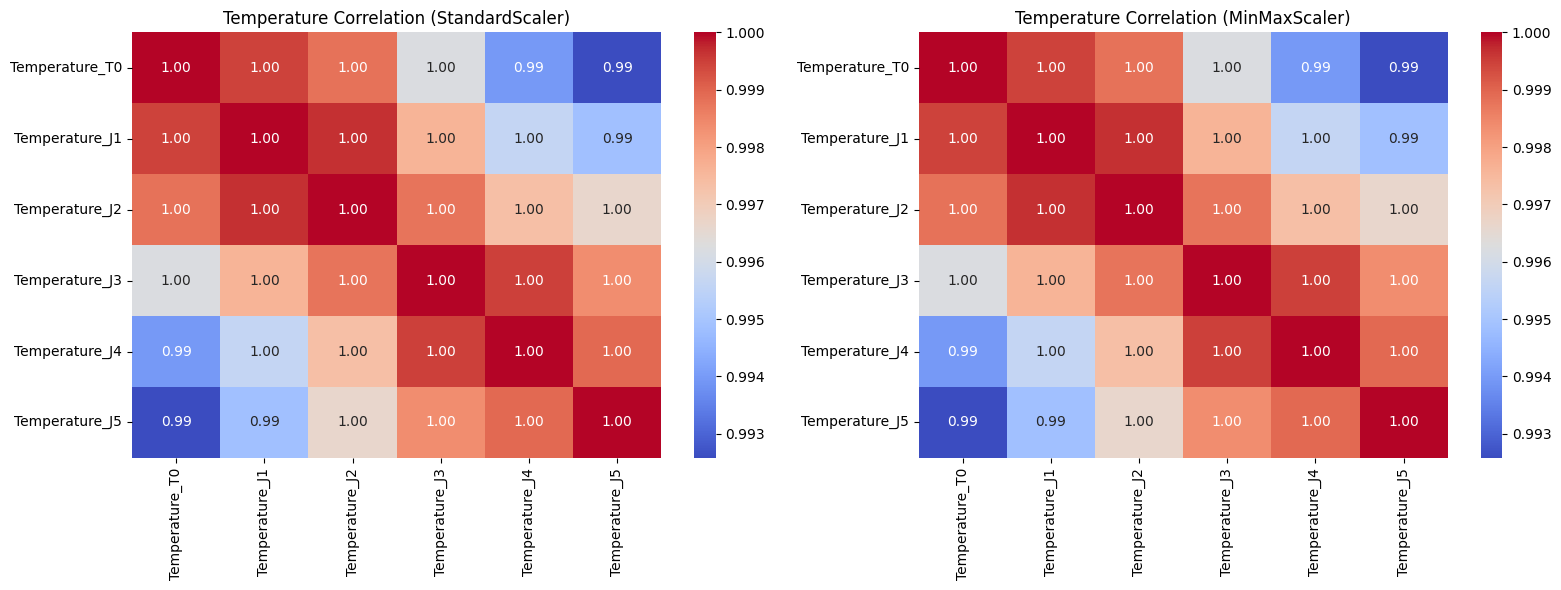

In [90]:
# Filter temperature related columns
temp_cols = [col for col in df_clean.columns if 'Temperature' in col]

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap for StandardScaled Data
sns.heatmap(df_clean[temp_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax1)
ax1.set_title('Temperature Correlation (StandardScaler)')

# Heatmap for MinMaxScaler Data
sns.heatmap(df_clean[temp_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax2)
ax2.set_title('Temperature Correlation (MinMaxScaler)')

plt.tight_layout()
plt.show()

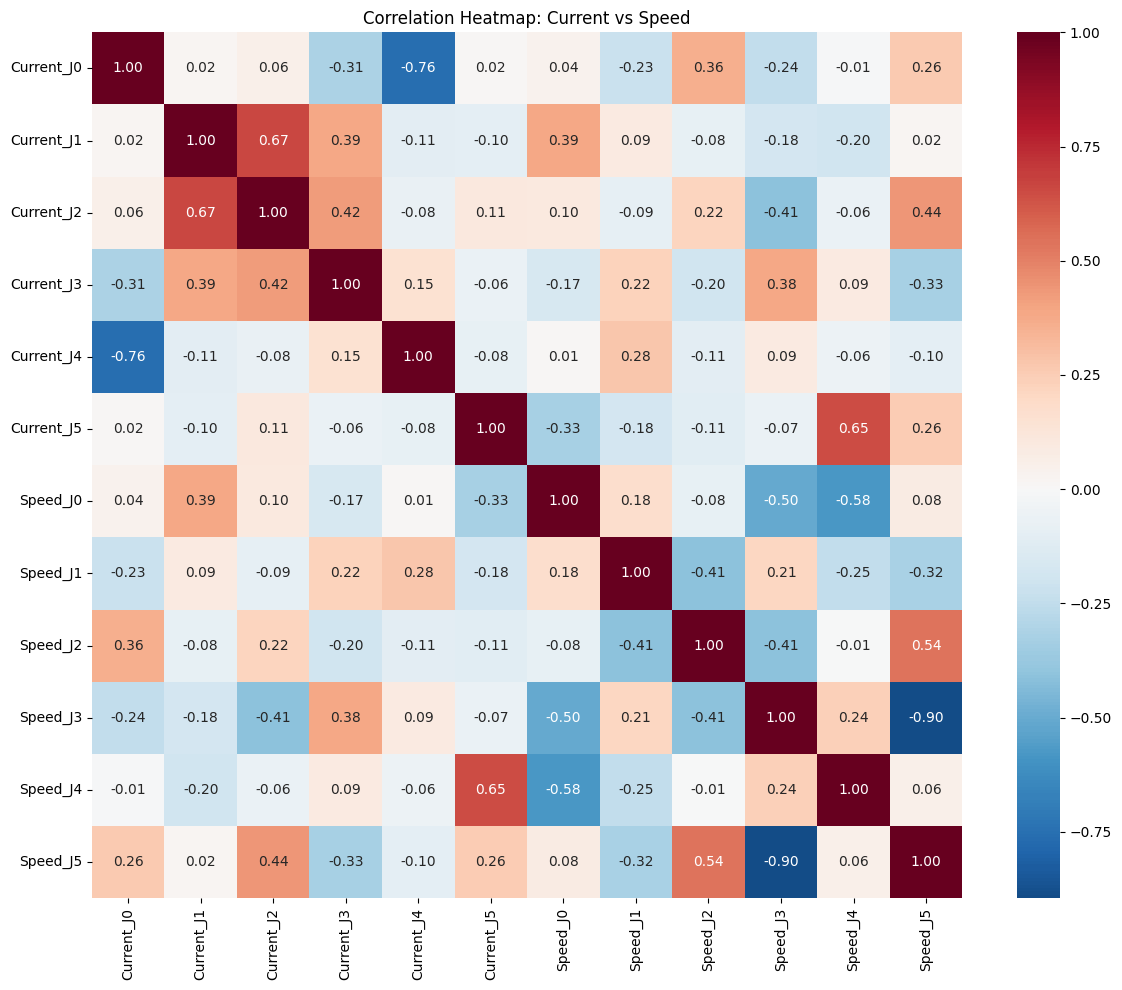

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

# Current와 Speed 관련 컬럼 필터링
current_cols = [col for col in df_clean.columns if 'Current' in col]
speed_cols = [col for col in df_clean.columns if 'Speed' in col]
feature_cols = current_cols + speed_cols

# 상관관계 행렬 계산
corr_matrix = df_clean[feature_cols].corr()

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', center=0)
plt.title('Correlation Heatmap: Current vs Speed')
plt.tight_layout()
plt.show()

In [91]:
# 6개 온도 컬럼 리스트
temp_cols = [
    "Temperature_T0",
    "Temperature_J1",
    "Temperature_J2",
    "Temperature_J3",
    "Temperature_J4",
    "Temperature_J5",
]

# 평균값 파생 변수 생성 후 기존 컬럼 삭제
df_clean["Temperature_Mean"] = df_clean[temp_cols].mean(axis=1)
df_clean = df_clean.drop(columns=temp_cols)

# 맨 앞으로 정렬 코드 추가
cols = ["Temperature_Mean"] + [col for col in df_clean.columns if col != "Temperature_Mean"]
df_clean = df_clean[cols]

In [92]:
df_clean

,Temperature_Mean,Current_J0,Current_J1,Current_J2,Current_J3,Current_J4,Current_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,Robot_ProtectiveStop,grip_lost
0,30.500000,0.109628,-2.024669,-1.531442,-0.998570,-0.062540,-0.152622,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,0,0
1,30.510417,0.595605,-2.278456,-0.866556,-0.206097,-1.062762,-0.260764,-7.390000e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,0,0
2,30.520833,-0.229474,-2.800408,-2.304336,-0.351499,-0.668869,0.039071,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,0,0
3,30.500000,0.065053,-3.687768,-1.217652,-1.209115,-0.819755,0.153903,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,0,0
4,30.531250,0.884140,-2.938830,-1.794076,-2.356471,-0.966427,0.178998,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7404,41.895833,-0.109017,-2.261695,-1.082678,-0.494714,-0.019447,0.023025,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.080013,0,0
7405,41.885417,-0.098536,-2.251992,-1.094420,-0.515789,-0.009186,0.047794,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.078740,0,0
7406,41.875000,-0.121100,-2.280791,-1.121319,-0.502406,-0.002978,0.028567,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.091471,0,0
7407,41.885417,-0.129370,-2.269061,-1.091610,-0.491158,-0.001136,0.049641,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.090026,0,0


# 피처 스케일링

In [93]:
from sklearn.preprocessing import StandardScaler

df_SD = df_clean.copy()
# 1. 스케일링할 입력 피처들만 선택 (마지막 2개 타겟 열 제외)
feature_cols = df_SD.columns[:-2]

# 2. StandardScaler 적용
scaler1 = StandardScaler()
df_SD[feature_cols] = scaler1.fit_transform(df_SD[feature_cols])

In [94]:
from sklearn.preprocessing import MinMaxScaler

df_MM = df_clean.copy()

feature_cols = df_MM.columns[:-2]

# MinMaxScaler 적용
scaler2 = MinMaxScaler()
df_MM[feature_cols] = scaler2.fit_transform(df_MM[feature_cols])


In [99]:
df_SD.tail()

,Temperature_Mean,Current_J0,Current_J1,Current_J2,Current_J3,Current_J4,Current_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,Robot_ProtectiveStop,grip_lost
7404,0.771846,-0.071093,0.045279,0.191334,0.214795,0.005583,0.171305,-0.011227,-0.001238,-0.005198,0.012807,0.021063,-0.009175,-0.374418,0,0
7405,0.768696,-0.058452,0.057402,0.172084,0.173866,0.021851,0.363115,-0.011227,-0.001238,-0.005198,0.012807,0.021063,-0.009175,-0.390569,0,0
7406,0.765545,-0.085668,0.021420,0.127982,0.199856,0.031693,0.214218,-0.011227,-0.001238,-0.005198,0.012807,0.021063,-0.009175,-0.229066,0,0
7407,0.768696,-0.095643,0.036076,0.176690,0.221701,0.034612,0.377421,-0.011227,-0.001238,-0.005198,0.012807,0.021063,-0.009175,-0.247401,0,0
7408,0.768696,-0.101745,0.066825,0.164656,0.199874,-0.004537,0.481087,-0.011227,-0.001238,-0.005198,0.012807,0.021063,-0.009175,-0.259181,0,0


In [100]:
df_MM.tail()

,Temperature_Mean,Current_J0,Current_J1,Current_J2,Current_J3,Current_J4,Current_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,Robot_ProtectiveStop,grip_lost
7404,0.994545,0.470232,0.514636,0.465471,0.506550,0.534557,0.573843,0.453186,0.349585,0.504918,0.482609,0.538462,0.541843,0.102829,0,0
7405,0.993636,0.471035,0.516044,0.463702,0.502789,0.535719,0.602408,0.453186,0.349585,0.504918,0.482609,0.538462,0.541843,0.100641,0,0
7406,0.992727,0.469307,0.511865,0.459649,0.505177,0.536423,0.580234,0.453186,0.349585,0.504918,0.482609,0.538462,0.541843,0.122520,0,0
7407,0.993636,0.468673,0.513567,0.464125,0.507185,0.536631,0.604539,0.453186,0.349585,0.504918,0.482609,0.538462,0.541843,0.120036,0,0
7408,0.993636,0.468286,0.517138,0.463019,0.505179,0.533834,0.619977,0.453186,0.349585,0.504918,0.482609,0.538462,0.541843,0.118440,0,0


# REGRESSION
## current,speed 데이터를 기반으로 tool current를 예측

In [103]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

# 1. 결측치 없는 클린 데이터 로드 및 분리
df_clean = df.dropna().copy()

# 입력 피처(X): 12개 조인트 피처
input_cols = [
    'Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5',
    'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5'
]
X = df_clean[input_cols]

# 타겟(y): 그리퍼 전류
y = df_clean['Tool_current']

# 2. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. StandardScaler 적용
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. 다항 피처 변환 (Degree=2) - 최적의 성능을 낸 비결!
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# 5. 회귀 모델 학습 및 평가
model = LinearRegression()
model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)

# 6. 결과 출력
print("--- [최적 피벗] 그리퍼 전류(Tool_current) 다항 회귀 결과 ---")
print(f"R² (결정계수): {r2_score(y_test, y_pred):.4f}")
print(f"MSE (평균제곱오차): {mean_squared_error(y_test, y_pred):.6f}")

--- [최적 피벗] 그리퍼 전류(Tool_current) 다항 회귀 결과 ---
R² (결정계수): 0.2340
MSE (평균제곱오차): 0.004207
